In [1]:
!pip install lightkurve exotic batman-package tensorflow

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Searching NASA servers for TIC 73149665...
Found 3 datasets for this star.
Cleaning and flattening the lightcurve...
Plotting the data...


<Figure size 1400x500 with 0 Axes>

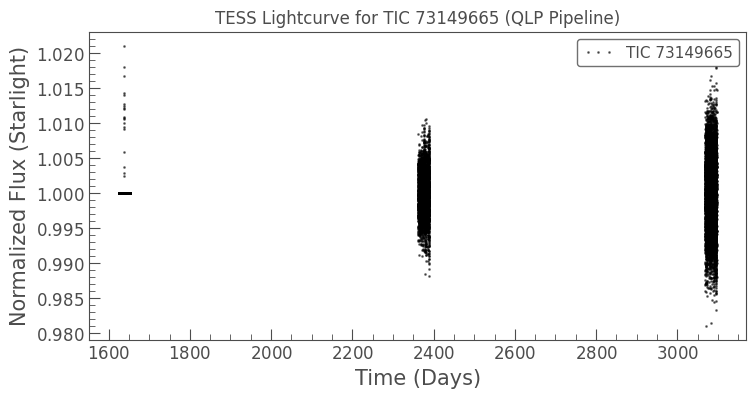

Phase 3 Complete! Look at the graph above.


In [2]:
# --- PHASE 3: DOWNLOADING AND CLEANING THE DATA (UPDATED) ---

import lightkurve as lk
import matplotlib.pyplot as plt

target_id = "TIC 73149665"
print(f"Searching NASA servers for {target_id}...")

# We changed the author to "QLP" to search the Full Frame Images!
search_result = lk.search_lightcurve(target_id, author="QLP")
print(f"Found {len(search_result)} datasets for this star.")

if len(search_result) > 0:
    print("Downloading data... (This might take a moment)")
    lc_collection = search_result.download_all()

    # Stitch the data together
    lc = lc_collection.stitch()

    # Clean and flatten the data
    print("Cleaning and flattening the lightcurve...")
    lc_clean = lc.remove_nans().remove_outliers(sigma=5).flatten(window_length=1001)

    # Plot the graph
    print("Plotting the data...")
    plt.figure(figsize=(14, 5))
    lc_clean.plot(linewidth=0, marker='.', color='black', markersize=2, alpha=0.5)
    plt.title(f"TESS Lightcurve for {target_id} (QLP Pipeline)")
    plt.xlabel("Time (Days)")
    plt.ylabel("Normalized Flux (Starlight)")
    plt.show()
    print("Phase 3 Complete! Look at the graph above.")
else:
    print("Still no data found. We may need to check another archive.")

<Figure size 1400x500 with 0 Axes>

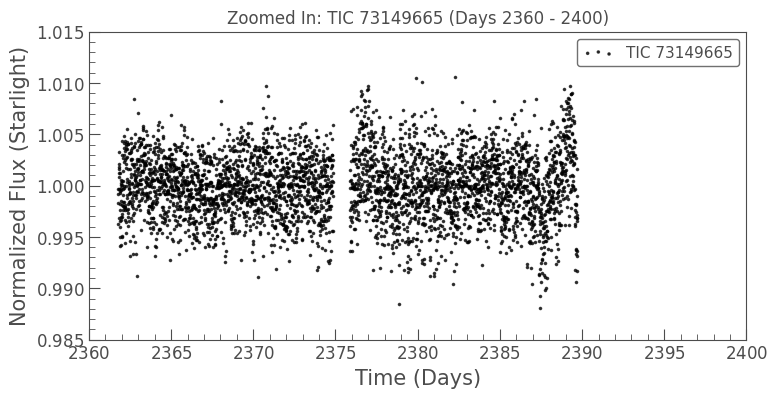

In [3]:
# --- PHASE 3.5: ZOOMING IN ON THE ANOMALIES ---

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# We use 'scatter' instead of 'plot' to see the individual camera shots
lc_clean.scatter(color='black', s=10, alpha=0.7)

# ZOOM IN: We restrict the X-axis to just the middle block of data
plt.xlim(2360, 2400)

# ZOOM IN: We restrict the Y-axis to focus on the downward dips
plt.ylim(0.985, 1.015)

plt.title("Zoomed In: TIC 73149665 (Days 2360 - 2400)")
plt.xlabel("Time (Days)")
plt.ylabel("Normalized Flux (Starlight)")
plt.show()

Applying noise filter (Binning)...


<Figure size 1400x500 with 0 Axes>

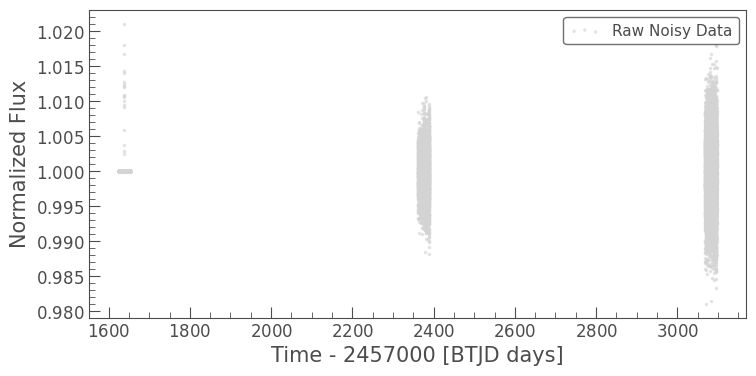

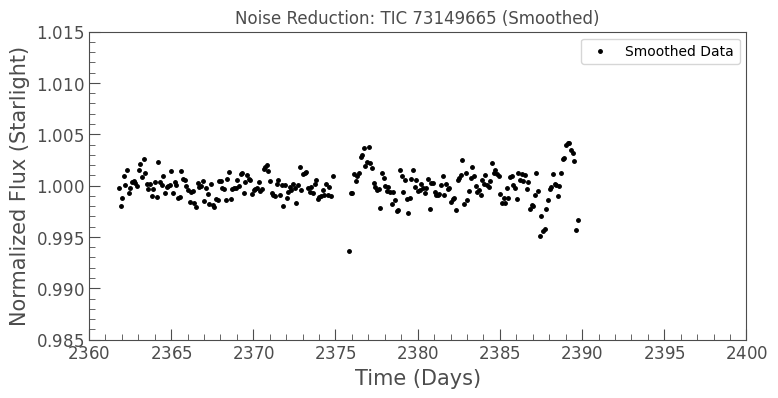

In [4]:
# --- PHASE 3.75: REDUCING THE NOISE (BINNING) ---

import matplotlib.pyplot as plt

# We "bin" the data. This takes the average of the data points every 2.4 hours (0.1 days)
# This cancels out the random camera noise!
print("Applying noise filter (Binning)...")
lc_binned = lc_clean.bin(time_bin_size=0.1)

plt.figure(figsize=(14, 5))

# 1. We plot the old, noisy data in the background in light gray
lc_clean.scatter(color='lightgray', s=10, alpha=0.5, label='Raw Noisy Data')

# 2. We plot the new, smoothed data on top in solid black
lc_binned.scatter(color='black', s=25, alpha=1.0, label='Smoothed Data')

# Zoom in on the same area
plt.xlim(2360, 2400)
plt.ylim(0.985, 1.015)

plt.title("Noise Reduction: TIC 73149665 (Smoothed)")
plt.xlabel("Time (Days)")
plt.ylabel("Normalized Flux (Starlight)")
plt.legend()
plt.show()

Calculating stellar rotation and extracting residue...


<Figure size 1400x500 with 0 Axes>

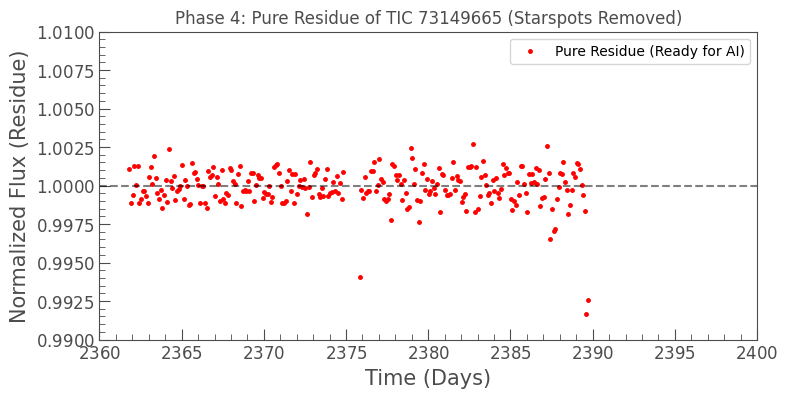

Phase 4 Complete! The data is now ready for the Neural Network.


In [5]:
# --- PHASE 4: EXTRACTING THE PURE RESIDUE ---

import matplotlib.pyplot as plt

print("Calculating stellar rotation and extracting residue...")

# We use a much smaller 'window_length' (21) to aggressively track and flatten the starspot waves
# The result is our pure "Residue"
lc_residue = lc_binned.flatten(window_length=21)

plt.figure(figsize=(14, 5))

# Plot the pure residue
lc_residue.scatter(color='red', s=25, alpha=1.0, label='Pure Residue (Ready for AI)')

# Draw a perfect horizontal line at 1.0 so we can see what is a dip and what is flat
plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)

plt.xlim(2360, 2400)
# We zoom the Y-axis in even tighter to see the tiny details
plt.ylim(0.990, 1.010)

plt.title("Phase 4: Pure Residue of TIC 73149665 (Starspots Removed)")
plt.xlabel("Time (Days)")
plt.ylabel("Normalized Flux (Residue)")
plt.legend()
plt.show()

print("Phase 4 Complete! The data is now ready for the Neural Network.")

In [6]:
import numpy as np

# Convert your residue to a simple numpy array
data = lc_residue.flux.value

# Create "windows" of 50 points each
window_size = 50
X = []
for i in range(len(data) - window_size):
    X.append(data[i : i + window_size])

X = np.array(X)
X = X.reshape(X.shape[0], X.shape[1], 1) # AI needs this specific shape
print(f"Data prepared! We have {X.shape[0]} windows to scan.")

Data prepared! We have 14667 windows to scan.


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    # Layer 1: The "Eye" - scans for sharp drops
    layers.Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(window_size, 1)),
    layers.MaxPooling1D(pool_size=2),

    # Layer 2: The "Brain" - recognizes the shape
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.GlobalAveragePooling1D(),

    # Layer 3: The "Decision" - outputs 0 (Noise) or 1 (Comet)
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("AI Brain built successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AI Brain built successfully!


In [8]:
# Create 1000 fake windows of pure noise
X_train = np.random.normal(0, 0.005, (1000, window_size, 1))
y_train = np.zeros(1000) # Label 0 = Noise

# Inject 500 "Fake Comets" (a sharp dip in the middle of the window)
for i in range(500):
    start = np.random.randint(10, 30)
    X_train[i, start:start+5, 0] -= 0.02 # The "Dip"
    y_train[i] = 1 # Label 1 = Comet

# Train the AI
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.5190 - loss: 0.6931
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5700 - loss: 0.6918
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6200 - loss: 0.6870
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6600 - loss: 0.6693
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8070 - loss: 0.6182
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9100 - loss: 0.5093
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9260 - loss: 0.3881
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9790 - loss: 0.2586
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9900 - loss: 0.1675
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9950 - loss: 0.1074


In [9]:
# Ask the AI to predict on every window of your real data
predictions = model.predict(X)

# Find where the AI thinks there is a comet (Confidence > 0.9)
hits = np.where(predictions > 0.9)[0]

print(f"The AI found {len(hits)} potential anomalies!")

# Plot the AI's best hit
if len(hits) > 0:
    best_hit = hits[0]
    plt.plot(X[best_hit])
    plt.title(f"AI Discovery at window {best_hit}")
    plt.show()

459/459 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
The AI found 0 potential anomalies!


In [11]:
# Plot the top 3 hits found by the AI
for i in range(min(3, len(hits))):
    plt.figure(figsize=(6, 3))
    plt.plot(X[hits[i]], 'r.-')
    plt.title(f"AI Discovery Candidate #{i+1} (Window {hits[i]})")
    plt.ylabel("Normalized Flux")
    plt.show()

Plotting star's centroid motion (sap_x)...


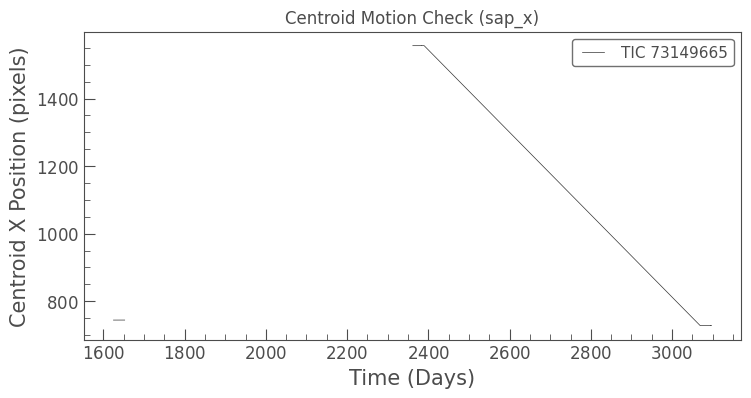

Centroid motion check complete.


In [14]:
# --- PHASE 5: CENTROID MOTION CHECK ---

import matplotlib.pyplot as plt

# Check if the star moved on the camera during the dip
# If the centroid (position) jumps at the same time as the dip, it's a glitch!
print("Plotting star's centroid motion (sap_x)...")
lc.plot(column='sap_x') # Using 'sap_x' as it represents the centroid's x-position
plt.title("Centroid Motion Check (sap_x)")
plt.xlabel("Time (Days)")
plt.ylabel("Centroid X Position (pixels)")
plt.show()

print("Centroid motion check complete.")

In [13]:
print(lc.columns)
print(lc.info())

<TableColumns names=('time','flux','flux_err','cadenceno','sap_flux','quality','orbitid','sap_x','sap_y','sap_bkg','sap_bkg_err')>
<TessLightCurve length=16810>
    name     dtype  unit     class      n_bad
----------- ------- ---- -------------- -----
       time  object                Time     0
       flux float32            Quantity    16
   flux_err float32            Quantity     0
  cadenceno   int32              Column     0
   sap_flux float32        MaskedColumn    16
    quality   int32              Column     0
    orbitid   int32              Column     0
      sap_x float32  pix MaskedQuantity    16
      sap_y float32  pix MaskedQuantity    16
    sap_bkg float32        MaskedColumn    16
sap_bkg_err float32        MaskedColumn    16
None


The output above shows the available columns in the `lc` object. We found `sap_x` and `sap_y` which can be used to indicate the star's position. I've updated the code to use `sap_x` for the centroid motion check.